# Modeling the MTA Hourly Ridership Dataset

This notebook is the modeling stage of the project. The goal here is to see how well hourly `ridership_total` can be forecasted using the station, calendar, and lag-based features created in preprocessing.

Since the target is continuous, this is a regression problem. Since the data is ordered through time, the model comparison also needs to respect time order.

## 1. Imports and Load Preprocessed Inputs

I am starting from the saved outputs of preprocessing rather than rebuilding everything here. That keeps this notebook focused on model comparison, tuning, and evaluation.

The files loaded below include the processed train and test feature matrices, the target values, the transformed feature names, and the fitted preprocessing object.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from scipy.sparse import load_npz

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, SGDRegressor, PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from lightgbm import LGBMRegressor
    lightgbm_available = True
except ModuleNotFoundError:
    lightgbm_available = False
    print("LightGBM is not installed. LightGBM sections will be skipped.")

try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ModuleNotFoundError:
    xgboost_available = False
    print("XGBoost is not installed. XGBoost sections will be skipped.")

X_train_processed = load_npz("../CSVs/X_train_processed.npz")
X_test_processed = load_npz("../CSVs/X_test_processed.npz")

y_train = pd.read_parquet("../CSVs/y_train.parquet")["ridership_total"]
y_test = pd.read_parquet("../CSVs/y_test.parquet")["ridership_total"]

all_feature_names = np.load("../CSVs/all_feature_names.npy", allow_pickle=True)
preprocessor = joblib.load("../CSVs/preprocessor.joblib")

## 2. Confirm the Loaded Data Shapes

Before fitting any models, I want to make sure the saved training and testing objects loaded correctly. This is also a quick check that the modeling notebook is connected to the preprocessing outputs the way it should be.

In [2]:
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Number of transformed features:", len(all_feature_names))

X_train_processed shape: (6034307, 485)
X_test_processed shape: (1508577, 485)
y_train shape: (6034307,)
y_test shape: (1508577,)
Number of transformed features: 485


## 3. Define the Modeling Objective

The target in this notebook is `ridership_total`, which makes this a regression problem rather than a classification one.

This is also a forecasting problem, so the way I validate the models matters. I do not want later observations leaking into earlier ones through a random split.

In [3]:
target_name = "ridership_total"
problem_type = "regression"
project_type = "forecasting"

print("Target:", target_name)
print("Problem type:", problem_type)
print("Project type:", project_type)

Target: ridership_total
Problem type: regression
Project type: forecasting


## 4. Create Expanding-Window Time-Series Validation Folds

Instead of using one fixed validation split, I am using an expanding-window backtest inside the training data. In each fold, the model trains on earlier observations and validates on the next block of later observations.

That setup is a better fit for forecasting because it shows whether a model stays strong across multiple periods instead of looking good on only one split.

In [ ]:
def make_expanding_folds(n_samples, initial_train_frac=0.50, val_frac=0.10, max_folds=3):
    initial_train_end = int(n_samples * initial_train_frac)
    val_size = int(n_samples * val_frac)

    folds = []

    for fold_num in range(max_folds):
        train_end = initial_train_end + fold_num * val_size
        val_start = train_end
        val_end = val_start + val_size

        if val_end > n_samples:
            break

        folds.append({
            "fold": fold_num + 1,
            "train_end": train_end,
            "val_start": val_start,
            "val_end": val_end
        })

    return folds


time_folds = make_expanding_folds(
    n_samples=X_train_processed.shape[0],
    initial_train_frac=0.50,
    val_frac=0.10,
    max_folds=3
)

time_folds

[{'fold': 1, 'train_end': 3017153, 'val_start': 3017153, 'val_end': 3620583},
 {'fold': 2, 'train_end': 3620583, 'val_start': 3620583, 'val_end': 4224013},
 {'fold': 3, 'train_end': 4224013, 'val_start': 4224013, 'val_end': 4827443}]

The exact fold settings were chosen to balance reliability and runtime. I used half of the training data as the initial training window so the models would have enough history to learn stable patterns before validation began. Each validation block uses 10% of the training data, which is large enough to produce meaningful error estimates while still leaving room for multiple folds. I used three folds to make the backtest more robust than a single split without making the notebook unnecessarily expensive to run.

In [5]:
for fold in time_folds:
    print(
        f"Fold {fold['fold']}: "
        f"train rows [0:{fold['train_end']}] | "
        f"validation rows [{fold['val_start']}:{fold['val_end']}]"
    )

Fold 1: train rows [0:3017153] | validation rows [3017153:3620583]
Fold 2: train rows [0:3620583] | validation rows [3620583:4224013]
Fold 3: train rows [0:4224013] | validation rows [4224013:4827443]


## 5. Define Evaluation Metrics

Because `ridership_total` is continuous, regression metrics make more sense here than classification metrics. I am using a few different ones so the comparison is not overly dependent on a single score.

- MAE shows the average absolute error in ridership units
- RMSE puts more weight on larger misses
- WMAPE scales the error relative to total ridership
- R² gives a broad sense of explained variation

In [6]:
def wmape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred).sum()
    denominator = np.abs(y_true).sum()
    return np.nan if denominator == 0 else numerator / denominator


def evaluate_regression(y_true, y_pred, model_name, split_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "Model": model_name,
        "Split": split_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred)
    }

## 6. Define Candidate Models and Hyperparameter Grids

The model set here is meant to balance baseline comparison, interpretability, scalability, and predictive power.

- `DummyRegressor` gives a simple baseline
- `Ridge` is a strong regularized linear option for sparse data
- `SGDRegressor` is another sparse-friendly linear model that scales well
- `PoissonRegressor` is worth testing because ridership is nonnegative and count-like
- `LightGBM` gives a nonlinear boosted-tree comparison
- `XGBoost` gives a second boosted-tree comparison so I am not relying on only one nonlinear approach

I am also not just fitting defaults. Each trainable model family is tested across multiple parameter settings so there is some real hyperparameter tuning in the notebook.

The hyperparameter ranges used here are meant to be a focused tuning pass rather than an exhaustive search. For the linear models, the main goal is to test different levels of regularization and different penalty structures. For the boosting models, the parameter choices vary model complexity and learning speed while keeping the search small enough to stay practical for this dataset. This gives a real model comparison without turning the notebook into a large optimization exercise.

In [7]:
candidate_builders = {
    "DummyRegressor_mean": lambda: DummyRegressor(strategy="mean"),

    "Ridge_alpha=1.0": lambda: Ridge(alpha=1.0, solver="lsqr"),
    "Ridge_alpha=10.0": lambda: Ridge(alpha=10.0, solver="lsqr"),
    "Ridge_alpha=100.0": lambda: Ridge(alpha=100.0, solver="lsqr"),

    "SGDRegressor_alpha=1e-4_penalty=l2": lambda: SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=1e-4,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ),
    "SGDRegressor_alpha=1e-3_penalty=l2": lambda: SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=1e-3,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ),
    "SGDRegressor_alpha=1e-4_penalty=elasticnet": lambda: SGDRegressor(
        loss="squared_error",
        penalty="elasticnet",
        alpha=1e-4,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ),
    "SGDRegressor_alpha=1e-3_penalty=elasticnet": lambda: SGDRegressor(
        loss="squared_error",
        penalty="elasticnet",
        alpha=1e-3,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ),

    "PoissonRegressor_alpha=0.1_max_iter=300": lambda: PoissonRegressor(
        alpha=0.1,
        max_iter=300
    ),
    "PoissonRegressor_alpha=1.0_max_iter=300": lambda: PoissonRegressor(
        alpha=1.0,
        max_iter=300
    ),
    "PoissonRegressor_alpha=10.0_max_iter=300": lambda: PoissonRegressor(
        alpha=10.0,
        max_iter=300
    ),
}

if lightgbm_available:
    candidate_builders.update({
        "LGBM_num_leaves=63_lr=0.05_n_estimators=200_min_child_samples=50": lambda: LGBMRegressor(
            objective="regression",
            num_leaves=63,
            learning_rate=0.05,
            n_estimators=200,
            min_child_samples=50,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ),
        "LGBM_num_leaves=127_lr=0.05_n_estimators=300_min_child_samples=50": lambda: LGBMRegressor(
            objective="regression",
            num_leaves=127,
            learning_rate=0.05,
            n_estimators=300,
            min_child_samples=50,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ),
        "LGBM_num_leaves=63_lr=0.10_n_estimators=200_min_child_samples=50": lambda: LGBMRegressor(
            objective="regression",
            num_leaves=63,
            learning_rate=0.10,
            n_estimators=200,
            min_child_samples=50,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ),
    })

if xgboost_available:
    candidate_builders.update({
        "XGB_max_depth=6_lr=0.05_n_estimators=200_subsample=0.8": lambda: XGBRegressor(
            objective="reg:squarederror",
            max_depth=6,
            learning_rate=0.05,
            n_estimators=200,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ),
        "XGB_max_depth=8_lr=0.05_n_estimators=300_subsample=0.8": lambda: XGBRegressor(
            objective="reg:squarederror",
            max_depth=8,
            learning_rate=0.05,
            n_estimators=300,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ),
        "XGB_max_depth=6_lr=0.10_n_estimators=200_subsample=0.8": lambda: XGBRegressor(
            objective="reg:squarederror",
            max_depth=6,
            learning_rate=0.10,
            n_estimators=200,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ),
    })

print("Number of candidate models:", len(candidate_builders))
print("\nCandidate models:")
for name in candidate_builders:
    print("-", name)

Number of candidate models: 17

Candidate models:
- DummyRegressor_mean
- Ridge_alpha=1.0
- Ridge_alpha=10.0
- Ridge_alpha=100.0
- SGDRegressor_alpha=1e-4_penalty=l2
- SGDRegressor_alpha=1e-3_penalty=l2
- SGDRegressor_alpha=1e-4_penalty=elasticnet
- SGDRegressor_alpha=1e-3_penalty=elasticnet
- PoissonRegressor_alpha=0.1_max_iter=300
- PoissonRegressor_alpha=1.0_max_iter=300
- PoissonRegressor_alpha=10.0_max_iter=300
- LGBM_num_leaves=63_lr=0.05_n_estimators=200_min_child_samples=50
- LGBM_num_leaves=127_lr=0.05_n_estimators=300_min_child_samples=50
- LGBM_num_leaves=63_lr=0.10_n_estimators=200_min_child_samples=50
- XGB_max_depth=6_lr=0.05_n_estimators=200_subsample=0.8
- XGB_max_depth=8_lr=0.05_n_estimators=300_subsample=0.8
- XGB_max_depth=6_lr=0.10_n_estimators=200_subsample=0.8


## 7. Run the Expanding-Window Backtest Across All Candidate Models

This is where the same fold structure gets applied to every candidate model. That way the comparison stays fair because each model is being judged on the same sequence of training and validation windows.

The result is a fold-level backtest table with one row per model per fold.

In [8]:
backtest_rows = []

for model_name, builder in candidate_builders.items():
    print(f"Running backtest for: {model_name}")

    for fold in time_folds:
        train_end = fold["train_end"]
        val_start = fold["val_start"]
        val_end = fold["val_end"]

        X_bt_train = X_train_processed[:train_end]
        y_bt_train = y_train.iloc[:train_end]

        X_bt_val = X_train_processed[val_start:val_end]
        y_bt_val = y_train.iloc[val_start:val_end]

        model = builder()
        model.fit(X_bt_train, y_bt_train)
        y_bt_pred = model.predict(X_bt_val)

        fold_result = evaluate_regression(
            y_true=y_bt_val,
            y_pred=y_bt_pred,
            model_name=model_name,
            split_name=f"fold_{fold['fold']}"
        )
        fold_result["Fold"] = fold["fold"]
        fold_result["Train_End_Row"] = train_end
        fold_result["Val_Start_Row"] = val_start
        fold_result["Val_End_Row"] = val_end

        backtest_rows.append(fold_result)

backtest_results_df = pd.DataFrame(backtest_rows)
backtest_results_df.head()

Running backtest for: DummyRegressor_mean
Running backtest for: Ridge_alpha=1.0
Running backtest for: Ridge_alpha=10.0
Running backtest for: Ridge_alpha=100.0
Running backtest for: SGDRegressor_alpha=1e-4_penalty=l2
Running backtest for: SGDRegressor_alpha=1e-3_penalty=l2
Running backtest for: SGDRegressor_alpha=1e-4_penalty=elasticnet
Running backtest for: SGDRegressor_alpha=1e-3_penalty=elasticnet
Running backtest for: PoissonRegressor_alpha=0.1_max_iter=300


c:\Users\Esh\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\glm.py:283: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
c:\Users\Esh\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\glm.py:283: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
c:\Users\Esh\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\glm.py:283: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the da

Running backtest for: PoissonRegressor_alpha=1.0_max_iter=300


c:\Users\Esh\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\glm.py:283: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
c:\Users\Esh\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\glm.py:283: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
c:\Users\Esh\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\glm.py:283: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the da

Running backtest for: PoissonRegressor_alpha=10.0_max_iter=300
Running backtest for: LGBM_num_leaves=63_lr=0.05_n_estimators=200_min_child_samples=50
Running backtest for: LGBM_num_leaves=127_lr=0.05_n_estimators=300_min_child_samples=50
Running backtest for: LGBM_num_leaves=63_lr=0.10_n_estimators=200_min_child_samples=50
Running backtest for: XGB_max_depth=6_lr=0.05_n_estimators=200_subsample=0.8
Running backtest for: XGB_max_depth=8_lr=0.05_n_estimators=300_subsample=0.8
Running backtest for: XGB_max_depth=6_lr=0.10_n_estimators=200_subsample=0.8


,Model,Split,MAE,RMSE,R2,WMAPE,Fold,Train_End_Row,Val_Start_Row,Val_End_Row
0,DummyRegressor_mean,fold_1,312.109282,651.910845,-3.029865e-03,0.978204,1,3017153,3017153,3620583
1,DummyRegressor_mean,fold_2,310.065279,648.135971,-8.939530e-04,1.004827,2,3620583,3620583,4224013
2,DummyRegressor_mean,fold_3,300.833385,626.276349,-6.298471e-08,1.029793,3,4224013,4224013,4827443
3,Ridge_alpha=1.0,fold_1,79.848564,191.116661,9.137946e-01,0.250259,1,3017153,3017153,3620583
4,Ridge_alpha=1.0,fold_2,88.903798,213.751133,8.911389e-01,0.288110,2,3620583,3620583,4224013


## 8. Review Fold-by-Fold Results

The fold-level results matter because I do not just care about one strong score. I also want to see whether a model is steady across time or whether its performance changes a lot from one window to another.

In [9]:
backtest_results_df.sort_values(["Model", "Fold"]).reset_index(drop=True)

,Model,Split,MAE,RMSE,R2,WMAPE,Fold,Train_End_Row,Val_Start_Row,Val_End_Row
0,DummyRegressor_mean,fold_1,312.109282,651.910845,-3.029865e-03,0.978204,1,3017153,3017153,3620583
1,DummyRegressor_mean,fold_2,310.065279,648.135971,-8.939530e-04,1.004827,2,3620583,3620583,4224013
2,DummyRegressor_mean,fold_3,300.833385,626.276349,-6.298471e-08,1.029793,3,4224013,4224013,4827443
3,LGBM_num_leaves=127_lr=0.05_n_estimators=300_m...,fold_1,41.440307,117.556649,9.673839e-01,0.129881,1,3017153,3017153,3620583
4,LGBM_num_leaves=127_lr=0.05_n_estimators=300_m...,fold_2,49.584988,139.109007,9.538931e-01,0.160690,2,3620583,3620583,4224013
5,LGBM_num_leaves=127_lr=0.05_n_estimators=300_m...,fold_3,41.386606,120.240413,9.631388e-01,0.141672,3,4224013,4224013,4827443
6,LGBM_num_leaves=63_lr=0.05_n_estimators=200_mi...,fold_1,45.660283,127.454133,9.616606e-01,0.143107,1,3017153,3017153,3620583
7,LGBM_num_leaves=63_lr=0.05_n_estimators=200_mi...,fold_2,54.334700,150.486950,9.460423e-01,0.176082,2,3620583,3620583,4224013
8,LGBM_num_leaves=63_lr=0.05_n_estimators=200_mi...,fold_3,45.502870,130.441253,9.566192e-01,0.155762,3,4224013,4224013,4827443
9,LGBM_num_leaves=63_lr=0.10_n_estimators=200_mi...,fold_1,43.560186,120.990796,9.654505e-01,0.136525,1,3017153,3017153,3620583


## 9. Aggregate Backtest Results Across Folds

Once the fold-level results are in place, I summarize them into average and standard deviation metrics. This makes it easier to compare both overall performance and consistency.

For a forecasting project, that consistency piece is important because a model that wins once but moves around a lot is harder to trust.

In [10]:
backtest_summary_df = (
    backtest_results_df
    .groupby("Model")
    .agg(
        mean_MAE=("MAE", "mean"),
        std_MAE=("MAE", "std"),
        mean_RMSE=("RMSE", "mean"),
        std_RMSE=("RMSE", "std"),
        mean_R2=("R2", "mean"),
        std_R2=("R2", "std"),
        mean_WMAPE=("WMAPE", "mean"),
        std_WMAPE=("WMAPE", "std")
    )
    .sort_values(by=["mean_MAE", "mean_RMSE", "mean_WMAPE"], ascending=[True, True, True])
    .reset_index()
)

backtest_summary_df

,Model,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2,std_R2,mean_WMAPE,std_WMAPE
0,LGBM_num_leaves=127_lr=0.05_n_estimators=300_m...,44.137300,4.717912,125.635356,11.745429,0.961472,0.006898,0.144081,0.015545
1,XGB_max_depth=8_lr=0.05_n_estimators=300_subsa...,45.346005,4.808073,127.679973,12.452039,0.960193,0.007434,0.148025,0.015824
2,LGBM_num_leaves=63_lr=0.10_n_estimators=200_mi...,46.195974,4.602517,129.242127,11.651572,0.959238,0.007054,0.150807,0.015286
3,LGBM_num_leaves=63_lr=0.05_n_estimators=200_mi...,48.499285,5.054231,136.127446,12.525065,0.954774,0.007971,0.158317,0.016635
4,XGB_max_depth=6_lr=0.10_n_estimators=200_subsa...,48.771473,4.882481,136.222886,12.901067,0.954712,0.008141,0.159189,0.015869
5,XGB_max_depth=6_lr=0.05_n_estimators=200_subsa...,51.266292,5.110524,144.580641,13.219945,0.948988,0.008918,0.167345,0.016796
6,Ridge_alpha=100.0,82.518558,5.534337,198.863606,12.899330,0.903739,0.011542,0.269378,0.018934
7,Ridge_alpha=10.0,82.537985,5.533149,198.862763,12.897491,0.903740,0.011541,0.269441,0.018931
8,Ridge_alpha=1.0,82.539962,5.533030,198.862685,12.897305,0.903740,0.011540,0.269448,0.018931
9,SGDRegressor_alpha=1e-3_penalty=l2,89.116670,10.751918,202.401406,11.391787,0.900442,0.008708,0.290010,0.022403


The final model is chosen mainly from average backtest MAE, with RMSE and WMAPE used as supporting checks. I also pay attention to consistency across folds, since a model that performs well across several validation windows is more convincing than one that looks strong in only a single period.

## 10. Visualize Average Backtest Performance

This chart compares the average MAE across the expanding-window folds. Lower MAE means the model is making smaller average errors, so the strongest models should appear with the smallest bars.

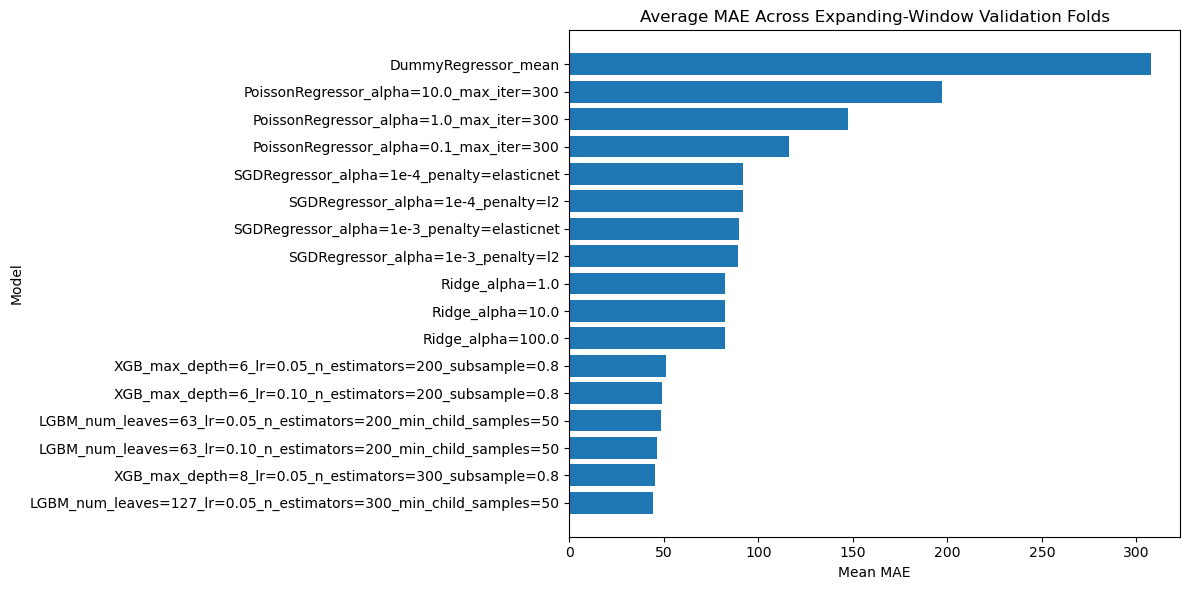

In [11]:
plot_df = backtest_summary_df.sort_values("mean_MAE", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(plot_df["Model"], plot_df["mean_MAE"])
plt.title("Average MAE Across Expanding-Window Validation Folds")
plt.xlabel("Mean MAE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 11. Select the Best Model from the Backtest

The best model is chosen from the average backtest results rather than from one single validation split. That gives me a stronger basis for model selection because the chosen model has to perform well more than once.

In [12]:
best_model_name = backtest_summary_df.iloc[0]["Model"]

print("Best backtest model:", best_model_name)
backtest_summary_df.head(10)

Best backtest model: LGBM_num_leaves=127_lr=0.05_n_estimators=300_min_child_samples=50


,Model,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2,std_R2,mean_WMAPE,std_WMAPE
0,LGBM_num_leaves=127_lr=0.05_n_estimators=300_m...,44.137300,4.717912,125.635356,11.745429,0.961472,0.006898,0.144081,0.015545
1,XGB_max_depth=8_lr=0.05_n_estimators=300_subsa...,45.346005,4.808073,127.679973,12.452039,0.960193,0.007434,0.148025,0.015824
2,LGBM_num_leaves=63_lr=0.10_n_estimators=200_mi...,46.195974,4.602517,129.242127,11.651572,0.959238,0.007054,0.150807,0.015286
3,LGBM_num_leaves=63_lr=0.05_n_estimators=200_mi...,48.499285,5.054231,136.127446,12.525065,0.954774,0.007971,0.158317,0.016635
4,XGB_max_depth=6_lr=0.10_n_estimators=200_subsa...,48.771473,4.882481,136.222886,12.901067,0.954712,0.008141,0.159189,0.015869
5,XGB_max_depth=6_lr=0.05_n_estimators=200_subsa...,51.266292,5.110524,144.580641,13.219945,0.948988,0.008918,0.167345,0.016796
6,Ridge_alpha=100.0,82.518558,5.534337,198.863606,12.899330,0.903739,0.011542,0.269378,0.018934
7,Ridge_alpha=10.0,82.537985,5.533149,198.862763,12.897491,0.903740,0.011541,0.269441,0.018931
8,Ridge_alpha=1.0,82.539962,5.533030,198.862685,12.897305,0.903740,0.011540,0.269448,0.018931
9,SGDRegressor_alpha=1e-3_penalty=l2,89.116670,10.751918,202.401406,11.391787,0.900442,0.008708,0.290010,0.022403


## 12. Feature Check: Test the `year` Feature in Ridge and LightGBM

One question that came up earlier was whether `year` is really doing much. `Month` makes intuitive sense as a seasonal feature, but `year` is less obvious when the overall time span is not especially long.

Instead of checking that in only one model, I am testing it in both:
- `Ridge`, to get a linear view of the feature
- `LightGBM`, to see whether a nonlinear model gets more value from it

That gives a more solid answer than testing `year` in only one model family. The `year` feature is only tested in Ridge and LightGBM on purpose. Ridge gives a linear view of whether the feature adds signal, while LightGBM shows whether a stronger nonlinear model can get more value from it. Together, these two checks give a reasonable feature comparison without repeating the same tests across every model in the notebook.

In [13]:
feature_names_series = pd.Series(all_feature_names)
year_present = "year" in feature_names_series.values

print("Is 'year' present in transformed features?", year_present)
if year_present:
    print(feature_names_series[feature_names_series == "year"])

Is 'year' present in transformed features? True
477    year
dtype: object


In [19]:
keep_mask = feature_names_series != "year"
X_train_no_year = X_train_processed[:, keep_mask.values]

year_fold_rows = []

for fold in time_folds:
    train_end = fold["train_end"]
    val_start = fold["val_start"]
    val_end = fold["val_end"]

    X_bt_train_with_year = X_train_processed[:train_end]
    X_bt_val_with_year = X_train_processed[val_start:val_end]

    X_bt_train_no_year = X_train_no_year[:train_end]
    X_bt_val_no_year = X_train_no_year[val_start:val_end]

    y_bt_train = y_train.iloc[:train_end]
    y_bt_val = y_train.iloc[val_start:val_end]

    ridge_with_year = Ridge(alpha=100.0, solver="lsqr")
    ridge_with_year.fit(X_bt_train_with_year, y_bt_train)
    pred_ridge_with_year = ridge_with_year.predict(X_bt_val_with_year)

    ridge_without_year = Ridge(alpha=100.0, solver="lsqr")
    ridge_without_year.fit(X_bt_train_no_year, y_bt_train)
    pred_ridge_without_year = ridge_without_year.predict(X_bt_val_no_year)

    ridge_with_year_result = evaluate_regression(
        y_bt_val, pred_ridge_with_year, "Ridge_with_year", f"fold_{fold['fold']}"
    )
    ridge_with_year_result["Fold"] = fold["fold"]
    year_fold_rows.append(ridge_with_year_result)

    ridge_without_year_result = evaluate_regression(
        y_bt_val, pred_ridge_without_year, "Ridge_without_year", f"fold_{fold['fold']}"
    )
    ridge_without_year_result["Fold"] = fold["fold"]
    year_fold_rows.append(ridge_without_year_result)

    if lightgbm_available:
        lgbm_with_year = LGBMRegressor(
            objective="regression",
            num_leaves=127,
            learning_rate=0.05,
            n_estimators=300,
            min_child_samples=50,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
        lgbm_with_year.fit(X_bt_train_with_year, y_bt_train)
        pred_lgbm_with_year = lgbm_with_year.predict(X_bt_val_with_year)

        lgbm_without_year = LGBMRegressor(
            objective="regression",
            num_leaves=127,
            learning_rate=0.05,
            n_estimators=300,
            min_child_samples=50,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
        lgbm_without_year.fit(X_bt_train_no_year, y_bt_train)
        pred_lgbm_without_year = lgbm_without_year.predict(X_bt_val_no_year)

        lgbm_with_year_result = evaluate_regression(
            y_bt_val, pred_lgbm_with_year, "LightGBM_with_year", f"fold_{fold['fold']}"
        )
        lgbm_with_year_result["Fold"] = fold["fold"]
        year_fold_rows.append(lgbm_with_year_result)

        lgbm_without_year_result = evaluate_regression(
            y_bt_val, pred_lgbm_without_year, "LightGBM_without_year", f"fold_{fold['fold']}"
        )
        lgbm_without_year_result["Fold"] = fold["fold"]
        year_fold_rows.append(lgbm_without_year_result)

year_check_df = pd.DataFrame(year_fold_rows)
print(year_check_df)

                    Model   Split        MAE        RMSE        R2     WMAPE  \
0         Ridge_with_year  fold_1  79.826074  191.117394  0.913794  0.250189   
1      Ridge_without_year  fold_1  79.813546  191.092723  0.913816  0.250149   
2      LightGBM_with_year  fold_1  41.440307  117.556649  0.967384  0.129881   
3   LightGBM_without_year  fold_1  41.535622  118.217080  0.967016  0.130180   
4         Ridge_with_year  fold_2  88.883941  213.754419  0.891136  0.288046   
5      Ridge_without_year  fold_2  88.892138  213.739344  0.891151  0.288072   
6      LightGBM_with_year  fold_2  49.584988  139.109007  0.953893  0.160690   
7   LightGBM_without_year  fold_2  50.024326  142.941508  0.951318  0.162114   
8         Ridge_with_year  fold_3  78.845659  191.719004  0.906287  0.269899   
9      Ridge_without_year  fold_3  78.744859  191.691566  0.906314  0.269554   
10     LightGBM_with_year  fold_3  41.386606  120.240413  0.963139  0.141672   
11  LightGBM_without_year  fold_3  42.08

## 13. Summarize the `year` Feature Check

This section pulls the `year` comparison into a cleaner summary table. If the metrics are nearly the same with and without `year`, then that is a sign that the feature is not adding much useful signal over the span covered by the dataset.

In [20]:
year_summary_df = (
    year_check_df
    .groupby("Model")
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_R2=("R2", "mean"),
        mean_WMAPE=("WMAPE", "mean")
    )
    .reset_index()
    .sort_values("mean_MAE")
)
print(year_summary_df)

                   Model   mean_MAE   mean_RMSE   mean_R2  mean_WMAPE
0     LightGBM_with_year  44.137300  125.635356  0.961472    0.144081
1  LightGBM_without_year  44.547692  129.616917  0.958921    0.145450
3     Ridge_without_year  82.483514  198.841211  0.903760    0.269259
2        Ridge_with_year  82.518558  198.863606  0.903739    0.269378


## 14. Refit the Best Model on the Full Training Set

After model selection is done, the winning configuration is retrained on the full training dataset. That lets the final model use all of the pre-test information before it gets evaluated once on the held-out test set.

In [21]:
final_model = candidate_builders[best_model_name]()
final_model.fit(X_train_processed, y_train)

final_model

LGBMRegressor(learning_rate=0.05, min_child_samples=50, n_estimators=300,
              n_jobs=-1, num_leaves=127, objective='regression',
              random_state=42, verbosity=-1)

## 15. Evaluate the Final Model on the Held-Out Test Set

This is the final check on generalization. The test set has stayed out of the backtest, so it gives the cleanest estimate of how the selected model performs on unseen later data. `PoissonRegressor` was included because ridership is nonnegative and count-like, so it was reasonable to test a model from that family. However, it produced convergence warnings and underperformed relative to the stronger linear and boosting models. Because of that, it was not treated as a serious final candidate.

In [22]:
y_test_pred = final_model.predict(X_test_processed)

test_result = evaluate_regression(
    y_true=y_test,
    y_pred=y_test_pred,
    model_name=best_model_name,
    split_name="test"
)

test_results_df = pd.DataFrame([test_result])
test_results_df

,Model,Split,MAE,RMSE,R2,WMAPE
0,LGBM_num_leaves=127_lr=0.05_n_estimators=300_m...,test,36.441853,94.512892,0.980531,0.115476


## 16. Save the Backtest Results and Final Model

This section saves the fold-level backtest results, the summarized comparison table, the optional `year` feature-check outputs, the final selected model, and the final test predictions.

In [23]:
joblib.dump(final_model, "../CSVs/final_model.joblib")

backtest_results_df.to_csv("../CSVs/model_backtest_fold_results.csv", index=False)
backtest_summary_df.to_csv("../CSVs/model_backtest_summary.csv", index=False)
test_results_df.to_csv("../CSVs/final_model_test_results.csv", index=False)

if year_present:
    year_check_df.to_csv("../CSVs/year_feature_check_fold_results.csv", index=False)
    year_summary_df.to_csv("../CSVs/year_feature_check_summary.csv", index=False)

pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_test_pred
}).to_parquet("../CSVs/final_model_test_predictions.parquet", index=False)

print("Backtest results and final model saved successfully.")

Backtest results and final model saved successfully.


## 17. Modeling Summary

This notebook used an expanding-window time-series backtest to compare multiple regression models for forecasting hourly subway ridership. The candidate set included a baseline `DummyRegressor`, sparse-friendly linear models such as `Ridge` and `SGDRegressor`, a generalized linear model using `PoissonRegressor`, and boosted tree models using `LightGBM` and `XGBoost`.

Based on the backtest results, the strongest model was `LightGBM` with `num_leaves=127`, `learning_rate=0.05`, `n_estimators=300`, and `min_child_samples=50`. Across the validation folds, this model achieved an average MAE of about 44.14, an average RMSE of about 125.64, an average R² of about 0.9615, and an average WMAPE of about 0.1441. This made it the best overall model in the notebook and stronger than the linear models, the Poisson model, and the baseline.

After retraining the selected LightGBM model on the full training data, the held-out test set results were even stronger: MAE = 36.44, RMSE = 94.51, R² = 0.9805, and WMAPE = 0.1155. These results show that hourly `ridership_total` can be forecasted effectively using the engineered station, calendar, and lag-based features.

The `year` feature check showed almost no meaningful difference for `Ridge`, but it did provide a small improvement for `LightGBM`. This suggests that `year` was not especially useful in the linear model, but it added some predictive value in the nonlinear boosted model. Overall, the results support the conclusion that hourly subway ridership is highly forecastable in this project, and that the tuned LightGBM model provided the strongest final performance.